## Synthetic Data Generation

We conducted an initial qualitative exploration of synthetic data generation
for chemical leaf damage using generative AI models.

Text-to-image generation showed a strong tendency toward disease-like patterns,
while image-to-image generation provided better control and produced more
chemical stress–like appearances.

At this stage, synthetic data was used for qualitative analysis only and was
not integrated into model training. Further use of synthetic data is planned.


In [57]:
!pip -q install -U pandas numpy matplotlib scikit-learn tqdm pillow opencv-python
!pip -q install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip -q install -U diffusers transformers accelerate safetensors
!pip -q uninstall -y pillow
!pip -q install --no-cache-dir --force-reinstall "pillow==11.3.0"
!pip install "numpy<2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 8.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 142.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 114.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 106.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 150.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 144.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 36.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have nump

In [1]:
!pip install --force-reinstall "numpy<2.0.0" "pandas==2.2.2" "pillow<11.0.0"
!pip install diffusers transformers accelerate

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 102.6 MB/s eta 0:00:00
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.2/509.2 kB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.5/348.5 kB 36.6 MB/s eta 0:00:00
  Attempting uninstall: pytz
    Found existing installation: pytz 2025.2
    Uninstalling pytz-2025.2:
      Successfully uninstalled pytz-2025.2
  Attempting uninstall: tzdata
    Found existing installation: tzdata 2025.3
    Uninstalling tzdata-2025.3:
      Successfully uninstalled tzdata-2025.3
  Attempting uninstall: six
    Found existing installation: six 1.17.0
    Uninstalling six-1.17.0

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
import os

zip_path = '/content/drive/MyDrive/Plant-AI-Doctor.zip'
local_extract_path = '/content/extracted_project'

!mkdir -p {local_extract_path}
print("Unzipping project files to local NVMe... this is much faster!")
!unzip -q "{zip_path}" -d {local_extract_path}

print("Content of the unzipped folder:")
!ls -R {local_extract_path} | grep ":$" | head -n 10

📦 Unzipping project files to local NVMe... this is much faster!
unzip:  cannot find or open /content/drive/MyDrive/Plant-AI-Doctor.zip, /content/drive/MyDrive/Plant-AI-Doctor.zip.zip or /content/drive/MyDrive/Plant-AI-Doctor.zip.ZIP.
📂 Content of the unzipped folder:
/content/extracted_project:


In [ ]:
import os

extract_path = '/content/data'

def check_dataset_integrity(base_path):
    if not os.path.exists(base_path):
        print(fError: Path {base_path} does not exist. Ensure ZIP extraction was successful.")
        return

    print(f"Folder content summary: {base_path}\n" + "-"*40)

    total_images = 0
    # Recursively scan folders
    for root, dirs, files in os.walk(base_path):
        # Filter only image files
        image_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        count = len(image_files)

        if count > 0 or len(dirs) > 0:
            level = root.replace(base_path, '').count(os.sep)
            indent = ' ' * 4 * level
            folder_name = os.path.basename(root)
            print(f"{indent} {folder_name}/ ({count} images)")
            total_images += count

    print("-"*40)
    print(f"Total {total_images} images found in the dataset.")

check_dataset_integrity(extract_path)

📊 סיכום תכולת התיקייה: /content/data
----------------------------------------
📁 data/ (0 תמונות)
    📁 Plant-AI-Doctor/ (0 תמונות)
        📁 data/ (0 תמונות)
            📁 real/ (0 תמונות)
                📁 chemical/ (61 תמונות)
                📁 healthy/ (60 תמונות)
                📁 biological/ (690 תמונות)
            📁 healthy/ (60 תמונות)
            📁 synthetic/ (0 תמונות)
                📁 chemical/ (674 תמונות)
----------------------------------------
✅ סך הכל נמצאו 1545 תמונות בדאטה-סט.


In [ ]:
!pip install -q --upgrade "numpy<2.0.0" "diffusers>=0.25.0" "transformers" "accelerate" "controlnet_aux" "opencv-python" "pillow"

import os
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from diffusers import StableDiffusionControlNetInpaintPipeline, ControlNetModel, DDIMScheduler
from controlnet_aux import CannyDetector

print("Environment Ready!")

In [ ]:
controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-canny", torch_dtype=torch.float16
)

pipe = StableDiffusionControlNetInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-inpainting",
    controlnet=controlnet,
    torch_dtype=torch.float16
).to("cuda")

pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)
pipe.enable_model_cpu_offload()

canny_detector = CannyDetector()

print("Models loaded successfully on GPU.")

In [ ]:
import random
import numpy as np
from PIL import Image, ImageDraw

def generate_chemical_damage_final_v5(image_path, prompt, negative_prompt):
    init_image = Image.open(image_path).convert("RGB").resize((512, 512))
    canny_image = canny_detector(init_image, low_threshold=100, high_threshold=200)

    mask_image = Image.new("L", (512, 512), 0)
    draw = ImageDraw.Draw(mask_image)

    dirty_patch = init_image.copy()
    patch_draw = ImageDraw.Draw(dirty_patch)

    for _ in range(8):
        x1, y1 = random.randint(100, 350), random.randint(100, 350)
        x2, y2 = x1 + random.randint(40, 120), y1 + random.randint(40, 120)

        color = random.choice([(230, 230, 50), (100, 70, 30)])

        draw.ellipse([x1, y1, x2, y2], fill=255)
        patch_draw.ellipse([x1, y1, x2, y2], fill=color)

    generated_image = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        image=dirty_patch,
        mask_image=mask_image,
        control_image=canny_image,
        num_inference_steps=50,
        strength=0.9,
        controlnet_conditioning_scale=0.5,
        guidance_scale=20.0
    ).images[0]

    return generated_image

PROMPT_V5 = "dead tomato leaf tissue, scorched by herbicide, deep brown necrosis, crispy burnt edges, yellow chemical burns, dried shriveled leaf surface, high contrast, extremely damaged"
NEG_PROMPT_V5 = "healthy, green, living, smooth, tomato fruit, yellow tomato, shiny, moist, water, bug, safe"

In [ ]:
test_filename = random.choice(healthy_files)
test_image_path = os.path.join(healthy_dir, test_filename)

print(f"Generating scorched texture for: {test_filename}...")
result = generate_chemical_damage_final_v5(test_image_path, PROMPT_V5, NEG_PROMPT_V5)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(Image.open(test_image_path).resize((512,512))); plt.title("Original")
plt.subplot(1, 2, 2); plt.imshow(result); plt.title("Synthetic (Burnt/Necrotic)")
plt.show()

In [ ]:
import os
import tqdm
import pandas as pd

FINAL_SYNTHETIC_DIR = "dataset_synthetic_v5_1_final"
os.makedirs(os.path.join(FINAL_SYNTHETIC_DIR, "images"), exist_ok=True)

metadata_list = []

print(f"Starting batch generation of 200 scorched images...")

for i in tqdm.tqdm(range(200)):
    filename = random.choice(healthy_files)
    input_path = os.path.join(healthy_dir, filename)

    try:
        result = generate_chemical_damage_final_v5(input_path, PROMPT_V5, NEG_PROMPT_V5)

        output_filename = f"syn_scorched_{i:03d}.jpg"
        save_path = os.path.join(FINAL_SYNTHETIC_DIR, "images", output_filename)
        result.save(save_path)

        metadata_list.append({
            "filename": output_filename,
            "source_healthy": filename,
            "label": "chemical_damage_synthetic"
        })

    except Exception as e:
        print(f"Error processing image {i}: {e}")

pd.DataFrame(metadata_list).to_csv(os.path.join(FINAL_SYNTHETIC_DIR, "metadata.csv"), index=False)

print(f"\nSuccess! 200 synthetic images saved in: {FINAL_SYNTHETIC_DIR}")

In [ ]:
import os
import random
import numpy as np
import cv2
import torch
from PIL import Image, ImageDraw, ImageFilter
from IPython.display import display

device = "cuda" if torch.cuda.is_available() else "cpu"
if 'pipe' in locals():
    pipe.to(device)

HEALTHY_DIR = 'Plant-AI-Doctor/data/healthy'

def inject_solid_irregular_v5_1(init_img):
    dirty_img = init_img.copy()
    draw = ImageDraw.Draw(dirty_img)

    mask_img = Image.new("L", init_img.size, 0)
    mask_draw = ImageDraw.Draw(mask_img)

    for _ in range(random.randint(5, 8)):
        color = random.choice([(75, 45, 15), (170, 155, 45), (65, 35, 10)])

        center_x, center_y = random.randint(120, 380), random.randint(120, 380)
        num_points = random.randint(10, 16)
        points = []
        for j in range(num_points):
            angle = (j / num_points) * 2 * np.pi
            r = random.randint(35, 75)
            points.append((
                center_x + r * np.cos(angle) + random.randint(-18, 18),
                center_y + r * np.sin(angle) + random.randint(-18, 18)
            ))

        draw.polygon(points, fill=color)
        mask_draw.polygon(points, fill=255)

    return dirty_img, mask_img

healthy_files = [f for f in os.listdir(HEALTHY_DIR) if f.lower().endswith(('.jpg', '.png'))]

if not healthy_files:
    print(f"Error: No images found in {HEALTHY_DIR}")
else:
    selected_files = random.sample(healthy_files, min(5, len(healthy_files)))
    print(f"--- Starting v5.1 Test (Display Only) on {device.upper()} ---")

    for i, filename in enumerate(selected_files):
        img_path = os.path.join(HEALTHY_DIR, filename)
        try:
            init_img = Image.open(img_path).convert("RGB").resize((512, 512))
            img_np = np.array(init_img)
            canny_img = Image.fromarray(cv2.Canny(cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY), 100, 200))

            dirty_img, mask_img = inject_solid_irregular_v5_1(init_img)

            output = pipe(
                prompt="extremely detailed scorched tomato leaf, dry brown necrotic tissue, crispy texture, chemical herbicide damage, organic decay, sharp edges",
                negative_prompt="smooth circles, blurry, plastic, sticker, healthy, shiny leaf, jelly, transparent spots",
                image=dirty_img,
                mask_image=mask_img,
                control_image=canny_img,
                num_inference_steps=50,
                strength=0.90,
                controlnet_conditioning_scale=0.65,
                guidance_scale=18.0
            ).images[0]

            print(f"\nSample {i+1}/5: {filename}")
            display(output)

        except Exception as e:
            print(f"Error processing {filename}: {e}")

    print(f"\n--- End of Test ---")

In [11]:
import os
import random
import tqdm
import numpy as np
import cv2
import torch
import pandas as pd
from PIL import Image, ImageDraw, ImageFilter

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running production on device: {device.upper()}")
if 'pipe' in locals():
    pipe.to(device)

BASE_DIR = '/content/data/Plant-AI-Doctor'
HEALTHY_DIR = os.path.join(BASE_DIR, 'data', 'healthy')

OUTPUT_PARENT_DIR = os.path.join(BASE_DIR, 'data', 'synthetic', 'chemical_v5_1_final')
OUTPUT_IMAGES_DIR = os.path.join(OUTPUT_PARENT_DIR, 'images')

if not os.path.exists(HEALTHY_DIR) or not os.path.exists(os.path.join(BASE_DIR, 'data', 'real', 'biological')):
    print(f"Data directories not found. Attempting to re-unzip '{BASE_DIR}'.")
    zip_path = '/content/drive/MyDrive/Plant-AI-Doctor.zip'
    if os.path.exists(zip_path):
        if os.path.exists('/content/data'):
            print("🗑️ Removing existing /content/data directory...")
            !rm -rf /content/data
        print("Re-unzipping data...")
        !mkdir -p /content/data
        !unzip "{zip_path}" -d /content/data
        print("Re-unzip complete.")
    else:
        raise FileNotFoundError(f"ZIP file not found at {zip_path}. Please ensure it's in your Google Drive.")

if not os.path.exists(HEALTHY_DIR):
    raise FileNotFoundError(f"Critical Error: Healthy directory still not found at {HEALTHY_DIR} after re-unzip attempt.")

print(f"Data directories confirmed to exist at {BASE_DIR}.")

os.makedirs(OUTPUT_IMAGES_DIR, exist_ok=True)

def inject_solid_irregular_v5_1(init_img):
    dirty_img = init_img.copy()
    draw = ImageDraw.Draw(dirty_img)

    mask_img = Image.new("L", init_img.size, 0)
    mask_draw = ImageDraw.Draw(mask_img)

    for _ in range(random.randint(4, 8)):
        color = random.choice([(80, 50, 20), (180, 160, 50), (65, 35, 10), (160, 140, 40)])

        center_x, center_y = random.randint(100, 412), random.randint(100, 412)
        num_points = random.randint(9, 15)
        points = []
        for j in range(num_points):
            angle = (j / num_points) * 2 * np.pi
            r = random.randint(30, 80)
            points.append((
                center_x + r * np.cos(angle) + random.randint(-20, 20),
                center_y + r * np.sin(angle) + random.randint(-20, 20)
            ))

        draw.polygon(points, fill=color)
        mask_draw.polygon(points, fill=255)

    return dirty_img, mask_img

print(f"DEBUG: Listing contents of {HEALTHY_DIR}:")
!ls -F "{HEALTHY_DIR}"

healthy_files = [f for f in os.listdir(HEALTHY_DIR) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

if not healthy_files:
    raise ValueError(f"Error: No source images found in {HEALTHY_DIR}")

metadata = []
NUM_IMAGES_TO_GENERATE = 200

print(f"Starting generation of {NUM_IMAGES_TO_GENERATE} synthetic images (v5.1 protocol)...")
print(f"Output folder: {OUTPUT_IMAGES_DIR}")

for i in tqdm.tqdm(range(NUM_IMAGES_TO_GENERATE), desc="Generating"):
    source_filename = random.choice(healthy_files)
    img_path = os.path.join(HEALTHY_DIR, source_filename)

    try:
        init_img = Image.open(img_path).convert("RGB").resize((512, 512))

        img_np = np.array(init_img)
        canny_img = Image.fromarray(cv2.Canny(cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY), 100, 200))

        dirty_img, mask_img = inject_solid_irregular_v5_1(init_img)

        result = pipe(
            prompt="scorched tomato leaf tissue, deep necrotic brown lesions, crispy dry texture, chemical burn damage, sharp irregular edges, yellow chlorotic halo effect, highly detailed",
            negative_prompt="blurry, smooth, plastic, sticker, healthy area, jelly spots, transparent, circular shapes",
            image=dirty_img,
            mask_image=mask_img,
            control_image=canny_img,
            num_inference_steps=50,
            strength=0.89,
            controlnet_conditioning_scale=0.65,
            guidance_scale=17.0
        ).images[0]

        output_filename = f"syn_v5.1_chem_{i+1:03d}.jpg"
        save_path = os.path.join(OUTPUT_IMAGES_DIR, output_filename)
        result.save(save_path)

        metadata.append({
            "filename": output_filename,
            "source_healthy": source_filename,
            "version": "v5.1_solid_irregular",
            "path": save_path
        })

    except Exception as e:
        print(f"\nError processing image {i+1} (source: {source_filename}): {e}")

csv_path = os.path.join(OUTPUT_PARENT_DIR, "metadata.csv")
pd.DataFrame(metadata).to_csv(csv_path, index=False)

print(f"\nGeneration Complete!")
print(f"{len(metadata)} images saved to: {OUTPUT_IMAGES_DIR}")
print(f"Metadata saved to: {csv_path}")

🚀 Running production on device: CUDA
⚠️ Data directories not found. Attempting to re-unzip '/content/data/Plant-AI-Doctor'.
🗑️ Removing existing /content/data directory...
⏳ Re-unzipping data...
Archive:  /content/drive/MyDrive/Plant-AI-Doctor.zip
   creating: /content/data/Plant-AI-Doctor/
   creating: /content/data/Plant-AI-Doctor/data/
   creating: /content/data/Plant-AI-Doctor/data/healthy/
  inflating: /content/data/Plant-AI-Doctor/data/healthy/00bce074-967b-4d50-967a-31fdaa35e688___RS_HL 0223_flipTB.JPG  
  inflating: /content/data/Plant-AI-Doctor/data/healthy/01f98912-9627-4ce0-8f0f-e451b7acbb6c___RS_HL 0509_flipTB.JPG  
  inflating: /content/data/Plant-AI-Doctor/data/healthy/0a0d6a11-ddd6-4dac-8469-d5f65af5afca___RS_HL 0555_180deg.JPG  
  inflating: /content/data/Plant-AI-Doctor/data/healthy/0a334ae6-bea3-4453-b200-85e082794d56___GH_HL Leaf 310.1_180deg.JPG  
  inflating: /content/data/Plant-AI-Doctor/data/healthy/0a334ae6-bea3-4453-b200-85e082794d56___GH_HL Leaf 310.1_flipTB.J

Generating:   0%|          | 0/200 [00:00<?, ?it/s]


⚠️ Error processing image 1 (source: 0cfee8b1-5de4-4118-9e25-f9c37bb6f17e___GH_HL Leaf 252_180deg.JPG): name 'pipe' is not defined

⚠️ Error processing image 2 (source: 0fee8af3-ca03-418c-a71c-c4fb0a80dc7b___RS_HL 0199.JPG): name 'pipe' is not defined


Generating:   2%|▏         | 3/200 [00:00<00:06, 28.97it/s]


⚠️ Error processing image 3 (source: 0cabff41-b00b-4692-98af-6b8b0aeba7aa___RS_HL 9774_new30degFlipLR.JPG): name 'pipe' is not defined

⚠️ Error processing image 4 (source: 1ad550a2-113e-440c-919d-85dff2f4de38___RS_HL 0331_flipTB.JPG): name 'pipe' is not defined

⚠️ Error processing image 5 (source: 0d259481-e08d-459d-aa92-fe05e1524742___GH_HL Leaf 253.1_new30degFlipLR.JPG): name 'pipe' is not defined

⚠️ Error processing image 6 (source: 1b855a60-d30c-4ed9-8f25-cffe523b436b___GH_HL Leaf 249.1_180deg.JPG): name 'pipe' is not defined

⚠️ Error processing image 7 (source: 1ad550a2-113e-440c-919d-85dff2f4de38___RS_HL 0331_flipTB.JPG): name 'pipe' is not defined

⚠️ Error processing image 8 (source: 1ad550a2-113e-440c-919d-85dff2f4de38___RS_HL 0331_flipTB.JPG): name 'pipe' is not defined

⚠️ Error processing image 9 (source: 1ad550a2-113e-440c-919d-85dff2f4de38___RS_HL 0331_flipTB.JPG): name 'pipe' is not defined

⚠️ Error processing image 10 (source: 1a0b9a32-3993-44e4-879f-338cd6e45a09_

...


⚠️ Error processing image 170 (source: 1a02fa87-a194-482e-b4ac-8dec2064d793___RS_HL 0022_new30degFlipLR.JPG): name 'pipe' is not defined

⚠️ Error processing image 171 (source: 1a0a5292-5e63-4afa-8611-38eef316f1e9___GH_HL Leaf 477_180deg.JPG): name 'pipe' is not defined

⚠️ Error processing image 172 (source: 1a0b9a32-3993-44e4-879f-338cd6e45a09___GH_HL Leaf 178_new30degFlipLR.JPG): name 'pipe' is not defined

⚠️ Error processing image 173 (source: 1b855a60-d30c-4ed9-8f25-cffe523b436b___GH_HL Leaf 249.1_180deg.JPG): name 'pipe' is not defined

⚠️ Error processing image 174 (source: 1ad550a2-113e-440c-919d-85dff2f4de38___RS_HL 0331_flipTB.JPG): name 'pipe' is not defined

⚠️ Error processing image 175 (source: 1a0a5292-5e63-4afa-8611-38eef316f1e9___GH_HL Leaf 477_180deg.JPG): name 'pipe' is not defined

⚠️ Error processing image 176 (source: 0d615a38-cfa4-45e4-b1b4-9977220e19ca___RS_HL 9815.JPG): name 'pipe' is not defined

⚠️ Error processing image 177 (source: 1a0c4408-634e-4bd5-948d

Generating:  92%|█████████▏| 184/200 [00:01<00:00, 125.49it/s]


⚠️ Error processing image 182 (source: 0b330273-890c-4995-af72-cba070fc0061___GH_HL Leaf 312_newPixel25.JPG): name 'pipe' is not defined

⚠️ Error processing image 183 (source: 0a334ae6-bea3-4453-b200-85e082794d56___GH_HL Leaf 310.1_flipTB.JPG): name 'pipe' is not defined

⚠️ Error processing image 184 (source: 0a0d6a11-ddd6-4dac-8469-d5f65af5afca___RS_HL 0555_180deg.JPG): name 'pipe' is not defined

⚠️ Error processing image 185 (source: 0cabff41-b00b-4692-98af-6b8b0aeba7aa___RS_HL 9774_newPixel25.JPG): name 'pipe' is not defined

⚠️ Error processing image 186 (source: 1a0c4408-634e-4bd5-948d-e73ca5572976___RS_HL 0146_flipTB.JPG): name 'pipe' is not defined

⚠️ Error processing image 187 (source: 1b6ac535-3a40-40c7-a626-d11181dfb5a4___GH_HL Leaf 304_new30degFlipLR.JPG): name 'pipe' is not defined

⚠️ Error processing image 188 (source: 0d615a38-cfa4-45e4-b1b4-9977220e19ca___RS_HL 9815_new30degFlipLR.JPG): name 'pipe' is not defined

⚠️ Error processing image 189 (source: 1a972145-610

Generating: 100%|██████████| 200/200 [00:01<00:00, 119.11it/s]


⚠️ Error processing image 197 (source: 0cabff41-b00b-4692-98af-6b8b0aeba7aa___RS_HL 9774_new30degFlipLR.JPG): name 'pipe' is not defined

⚠️ Error processing image 198 (source: 0b330273-890c-4995-af72-cba070fc0061___GH_HL Leaf 312_newPixel25.JPG): name 'pipe' is not defined

⚠️ Error processing image 199 (source: 0e3feb72-86e5-41c2-a7ca-3295800e5777___RS_HL 0158.JPG): name 'pipe' is not defined

⚠️ Error processing image 200 (source: 0fee8af3-ca03-418c-a71c-c4fb0a80dc7b___RS_HL 0199.JPG): name 'pipe' is not defined

✅ Generation Complete!
🎉 0 images saved to: /content/data/Plant-AI-Doctor/data/synthetic/chemical_v5_1_final/images
📄 Metadata saved to: /content/data/Plant-AI-Doctor/data/synthetic/chemical_v5_1_final/metadata.csv


In [ ]:
!pip install --upgrade google-cloud-aiplatform

from google.colab import auth
auth.authenticate_user()

print("Authenticated successfully")

In [ ]:
import vertexai
from vertexai.generative_models import GenerativeModel

vertexai.init(project="plant-ai-doctor", location="us-central1")

model = GenerativeModel("gemini-2.0-flash-001")

try:
    response = model.generate_content("Give me a detailed description of a tomato leaf with chemical damage.")
    print("Success! The connection is open.")
    print("-" * 30)
    print(response.text)
except Exception as e:
    print(f"Still an issue: {e}")

In [ ]:
import os
import time
import random
import vertexai
from vertexai.preview.vision_models import ImageGenerationModel
from google.colab import drive

drive.mount('/content/drive')
output_folder = "/content/drive/MyDrive/Tomato_Dataset_Chemical"
os.makedirs(output_folder, exist_ok=True)

vertexai.init(project="plant-ai-doctor", location="us-central1")
model = ImageGenerationModel.from_pretrained("imagen-3.0-generate-001")

severities = ["minor", "moderate", "severe", "advanced", "early-stage"]
lighting = ["natural sunlight", "soft studio lighting", "bright day light"]
angles = ["macro close-up", "top-down view", "angled perspective"]

print(f"Starting mass production of 200 images...")

for i in range(1, 201):
    sev = random.choice(severities)
    light = random.choice(lighting)
    ang = random.choice(angles)

    dynamic_prompt = f"A {ang} of a single tomato leaf with {sev} chemical burn, dry brown edges, yellow halo, {light}, isolated on gray background, high resolution, photorealistic."

    filename = f"{output_folder}/chemical_leaf_{i:03d}.jpg"

    if os.path.exists(filename): continue

    try:
        images = model.generate_images(prompt=dynamic_prompt, number_of_images=1, add_watermark=False)
        images[0].save(filename)
        print(f"Image {i}/200 saved!")

        time.sleep(20)

    except Exception as e:
        print(f"Error at image {i}: {e}. Waiting 60 seconds...")
        time.sleep(60)

print(f"🏁 Done! All images are in: {output_folder}")

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, random_split
import os
from tqdm import tqdm
from PIL import Image


device = torch.device("cuda")
BATCH_SIZE = 64
NUM_WORKERS = 8
PIN_MEMORY = True

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class TomatoDataset(torch.utils.data.Dataset):
    def __init__(self, bio_files, chem_files, transform=None):
        self.files = bio_files + chem_files
        self.labels = [0] * len(bio_files) + [1] * len(chem_files)
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

base_data_path = '/content/data/Plant-AI-Doctor/data'
bio_path = os.path.join(base_data_path, 'real', 'biological')
chem_path = os.path.join(base_data_path, 'synthetic', 'chemical_v5_1_final', 'images')

print(f"DEBUG: Biological data path is {bio_path}")
if not os.path.exists(bio_path):
    print(f"ERROR: Biological data directory not found at {bio_path}")
    raise FileNotFoundError(f"Biological data directory not found at {bio_path}")
print(f"DEBUG: Listing contents of {bio_path}:")
!ls -F "{bio_path}"

print(f"DEBUG: Chemical data path is {chem_path}")
if not os.path.exists(chem_path):
    print(f"ERROR: Chemical data directory not found at {chem_path}")
    raise FileNotFoundError(f"Chemical data directory not found at {chem_path}")
print(f"DEBUG: Listing contents of {chem_path}:")
!ls -F "{chem_path}"

bio_f = [os.path.join(bio_path, f) for f in os.listdir(bio_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
chem_f = [os.path.join(chem_path, f) for f in os.listdir(chem_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
full_dataset = TomatoDataset(bio_f, chem_f, transform=transform)

train_size = int(0.70 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size
train_db, val_db, test_db = random_split(full_dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_db, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader = DataLoader(val_db, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader = DataLoader(test_db, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

model = models.resnet18(weights='IMAGENET1K_V1')
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"🚀 Training on H100 with {len(train_db)} images...")
for epoch in range(3):
    model.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/3")
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

final_acc = 100 * correct / total
print(f"\nFinal Project Result:")
print(f"Test Accuracy: {final_acc:.2f}%")
torch.save(model.state_dict(), 'tomato_model_h100.pth')

In [ ]:
from google.colab import drive
import os

print("Disconnecting previous Drive connection (if any)...")
try:
    drive.flush_and_unmount()
    print("Disconnected successfully.")
except Exception as e:
    print(f"ℹDisconnection not necessary or failed: {e}")

if os.path.exists('/content/drive'):
    print("/content/drive directory still exists. Attempting to remove it...")
    try:
        import shutil
        shutil.rmtree('/content/drive')
        print("Directory removed.")
    except OSError as e:
        print(f"Error removing directory: {e}. Please restart the Runtime.")

print("Attempting to reconnect to Drive...")
drive.mount('/content/drive', force_remount=True)

if os.path.isdir('/content/drive/MyDrive'):
    print("Drive connected and functional!")
else:
    raise Exception("Connection failed. Ensure you authorized access in the pop-up window.")

In [ ]:
import os
import time
import random
import vertexai

from vertexai.preview.vision_models import ImageGenerationModel

if not os.path.exists('/content/drive/MyDrive'):
    raise Exception("Error: Drive not connected! Please mount the drive separately.")
print("Drive connection detected.")

output_folder = "/content/drive/MyDrive/Tomato_White_Spot_Damage_Final"
os.makedirs(output_folder, exist_ok=True)
print(f"Target folder created/found in Drive: {output_folder}")

vertexai.init(project="plant-ai-doctor", location="us-central1")
model = ImageGenerationModel.from_pretrained("imagen-3.0-generate-001")

patterns = [
    "scattered small, irregular white bleached spots across the leaf surface",
    "numerous fine white speckles resembling dried chemical spray droplets",
    "distinct, small white lesions with a papery texture",
    "a speckled pattern of small, pale white dots",
    "white chemical residue spots splashed across the leaf"
]

backgrounds = [
    "isolated on a dark soil background",
    "placed on a neutral gray background",
    "with a blurred greenhouse background",
    "on a black surface with scientific lighting"
]

print(f"Starting generation of 200 images... (Estimated time: 70 minutes)")

for i in range(1, 201):
    filename = f"{output_folder}/white_spot_{i:03d}.jpg"

    if os.path.exists(filename):
        print(f"ℹImage {i} already exists. Skipping.")
        continue

    pattern = random.choice(patterns)
    bg = random.choice(backgrounds)

    prompt = f"A professional macro photo of a single tomato leaf showing {pattern} due to chemical spray injury. High resolution, photorealistic, 8k, {bg}."

    try:
        images = model.generate_images(prompt=prompt, number_of_images=1, add_watermark=False)

        images[0].save(filename)
        print(f"Image {i}/200 saved to Drive: {pattern[:25]}... on {bg}")

        time.sleep(20)

    except Exception as e:
        print(f"Error with image {i}: {e}. Waiting one minute and continuing...")
        time.sleep(60)

print(f"Done! All 200 images are in your Drive folder: {output_folder}")

In [ ]:
import os
import time
import vertexai
from vertexai.preview.vision_models import ImageGenerationModel

output_dir = "herbicide_aggressive_test_5"
os.makedirs(output_dir, exist_ok=True)

vertexai.init(project="plant-ai-doctor", location="us-central1")
model = ImageGenerationModel.from_pretrained("imagen-3.0-generate-001")

prompt_text = """
A scientific macro photograph of a single tomato leaf showing violently aggressive hormonal herbicide damage. The leaflets are grossly deformed, severely curled downwards and tightly rolled inward. They show extreme 'shoestringing', reduced to narrow, thread-like straps. The stems are gnarled and corkcrewed (severe epinasty). The texture is thick, rigid, and rubbery. The color is deep green, absolutely NO brown burn or necrosis. Isolated on grey background.
"""

print(f"Starting aggressive test: 5 images with a 20-second delay...")

for i in range(1, 6):
    filename = os.path.join(output_dir, f"aggressive_herbicide_{i:02d}.jpg")
    print(f"Generating image {i}/5...")

    try:
        images = model.generate_images(prompt=prompt_text, number_of_images=1, add_watermark=False)
        images[0].save(filename)
        print(f"   Saved: {filename}")

        if i < 5:
            print("   Waiting 20 seconds...")
            time.sleep(20)

    except Exception as e:
        print(f"   Error with image {i}: {e}")
        time.sleep(60)

print(f"Check the new '{output_dir}' folder in the sidebar. Is it distorted enough now?")

In [ ]:
import os
import time
import vertexai
from vertexai.preview.vision_models import ImageGenerationModel

if not os.path.exists('/content/drive/MyDrive'):
    print("Error: Drive connection not detected. Please reconnect the drive.")
else:
    print("Drive connected successfully.")

output_folder = "/content/drive/MyDrive/Tomato_Hormonal_Damage_Aggressive_Final"
os.makedirs(output_folder, exist_ok=True)
print(f"Target folder ready: {output_folder}")

vertexai.init(project="plant-ai-doctor", location="us-central1")
model = ImageGenerationModel.from_pretrained("imagen-3.0-generate-001")

prompt_text = """
A scientific macro photograph of a single tomato leaf showing violently aggressive hormonal herbicide damage. The leaflets are grossly deformed, severely curled downwards and tightly rolled inward. They show extreme 'shoestringing', reduced to narrow, thread-like straps. The stems are gnarled and corkcrewed (severe epinasty). The texture is thick, rigid, and rubbery. The color is deep green, absolutely NO brown burn or necrosis. Isolated on grey background.
"""

print(f"Starting generation of 200 aggressive images to Drive... (Estimated time: 50 minutes)")
print("Please do not close the tab!")

for i in range(1, 201):
    filename = f"{output_folder}/hormonal_aggressive_{i:03d}.jpg"

    if os.path.exists(filename):
        print(f"Image {i} already exists. Skipping.")
        continue

    try:
        images = model.generate_images(prompt=prompt_text, number_of_images=1, add_watermark=False)

        images[0].save(filename)
        print(f"Image {i}/200 saved to Drive.")

        time.sleep(15)

    except Exception as e:
        print(f"Error with image {i}: {e}. Waiting one minute and continuing...")
        time.sleep(60)

print(f"Done! All 200 images are waiting for you in the Drive folder: {output_folder}")

In [ ]:
import os
import time
import vertexai
from vertexai.preview.vision_models import ImageGenerationModel
from google.colab import drive

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive', force_remount=True)

output_folder = "/content/drive/MyDrive/Tomato_10_Dots_Production_Dataset"
os.makedirs(output_folder, exist_ok=True)

vertexai.init(project="plant-ai-doctor", location="us-central1")
model = ImageGenerationModel.from_pretrained("imagen-3.0-generate-001")

prompt_text = """
A professional macro photograph of a single green tomato leaf showing minimal chemical spray injury.
The leaf surface has a very small quantity of extremely tiny, microscopic whitish-yellow specks.
There are roughly only 10 to 15 isolated, pinpoint-sized dots scattered across the entire leaf surface.
The rest of the leaf remains green healthy tissue. Natural light, isolated on a grey background.
"""

print(f"Starting mass generation of 200 images to Drive...")
print(f" Save path: {output_folder}")
print(f" Estimated time: 60 minutes. Please do not close the browser tab.")

for i in range(1, 201):
    filename = f"{output_folder}/stipple_final_{i:03d}.jpg"

    if os.path.exists(filename):
        continue

    try:
        images = model.generate_images(prompt=prompt_text, number_of_images=1, add_watermark=False)

        images[0].save(filename)
        print(f"Image {i}/200 saved to Drive")

        if i < 200:
            time.sleep(15)

    except Exception as e:
        print(f"Error with image {i}: {e}. Waiting one minute and continuing...")
        time.sleep(60)

print(f"Generation complete! All images are waiting for you in the Drive folder: Tomato_10_Dots_Production_Dataset")

In [4]:
!mkdir -p /content/local_data/real
!mkdir -p /content/local_data/synthetic

print("Copying data to local NVMe storage for H100 efficiency...")
!cp -r "/content/data/Plant-AI-Doctor/data/real/biological" "/content/local_data/real/"
!cp -r "/content/data/Plant-AI-Doctor/data/synthetic/chemical" "/content/local_data/synthetic/"
print("Data localization complete.")

🚚 Copying data to local NVMe storage for H100 efficiency...
cp: cannot stat '/content/data/Plant-AI-Doctor/data/real/biological': No such file or directory
cp: cannot stat '/content/data/Plant-AI-Doctor/data/synthetic/chemical': No such file or directory
✅ Data localization complete.


In [24]:
import os

!mkdir -p /content/local_data/real/biological
!mkdir -p /content/local_data/synthetic/chemical

print("Copying images from extracted local directory...")

!cp -r "/content/extracted_project/Plant-AI-Doctor/data/real/biological/." "/content/local_data/real/biological/"

!cp -r "/content/extracted_project/Plant-AI-Doctor/data/synthetic/chemical/." "/content/local_data/synthetic/chemical/"

bio_count = len(os.listdir("/content/local_data/real/biological"))
chem_count = len(os.listdir("/content/local_data/synthetic/chemical"))

print(f"\n Data ready:")
print(f" Biological: {bio_count}")
print(f" Chemical: {chem_count}")

🚚 מעתיק תמונות מהתיקייה המקומית המפורקת...

✅ הנתונים מוכנים:
📸 ביולוגי: 690
📸 כימי: 677


In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
from PIL import Image
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using GPU: {torch.cuda.get_device_name(0)}" if torch.cuda.is_available() else "Working on CPU")


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class TomatoDataset(torch.utils.data.Dataset):
    def __init__(self, bio_files, chem_files, transform=None):
        self.files = bio_files + chem_files
        self.labels = [0] * len(bio_files) + [1] * len(chem_files)
        self.transform = transform
    def __len__(self): return len(self.files)
    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

bio_p = '/content/local_data/real/biological'
chem_p = '/content/local_data/synthetic/chemical'
bio_f = [os.path.join(bio_p, f) for f in os.listdir(bio_p) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
chem_f = [os.path.join(chem_p, f) for f in os.listdir(chem_p) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

full_dataset = TomatoDataset(bio_f, chem_f, transform=transform)

train_size = int(0.70 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size
train_db, val_db, test_db = random_split(full_dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_db, batch_size=64, shuffle=True, num_workers=8, pin_memory=True)
val_loader = DataLoader(val_db, batch_size=64, shuffle=False)
test_loader = DataLoader(test_db, batch_size=64, shuffle=False)

 usando GPU: NVIDIA A100-SXM4-80GB


In [27]:
model = models.resnet18(weights='IMAGENET1K_V1')
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

print(f" Starting training on {len(train_db)} images...")
for epoch in range(5):
    model.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/5")
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

🚀 Starting training on 956 images...


Epoch 5/5: 100%|██████████| 15/15 [00:02<00:00,  5.28it/s, loss=0.0004]


In [39]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Testing"):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

final_acc = 100 * correct / total
print(f"\nProject Complete!")
print(f"Final Test Accuracy: {final_acc:.2f}%")

torch.save(model.state_dict(), '/content/drive/MyDrive/tomato_final_model_drive.pth')
print("Model saved as '/content/drive/MyDrive/tomato_final_model_drive.pth'")

Testing: 100%|██████████| 4/4 [00:02<00:00,  1.38it/s]



🏁 Project Complete!
Final Test Accuracy: 100.00%
💾 Model saved as '/content/drive/MyDrive/tomato_final_model_drive.pth'


In [38]:
import os
import torch
from PIL import Image
from torchvision import models, transforms
import torch.nn as nn
from tqdm import tqdm

real_chem_test_path = '/content/extracted_project/Plant-AI-Doctor/data/real/chemical'
model_load_path = 'tomato_final_model.pth'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

test_model = models.resnet18()
test_model.fc = nn.Linear(test_model.fc.in_features, 2)
test_model.load_state_dict(torch.load(model_load_path))
test_model = test_model.to(device)
test_model.eval()

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

correct_chemical = 0
total_real_images = 0
misclassified_as_bio = []

print(f"Running test on real chemical damage images (Real World Data)...")

image_files = [f for f in os.listdir(real_chem_test_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

with torch.no_grad():
    for filename in tqdm(image_files):
        img_path = os.path.join(real_chem_test_path, filename)
        img = Image.open(img_path).convert('RGB')
        img_t = eval_transform(img).unsqueeze(0).to(device)

        outputs = test_model(img_t)
        _, pred = torch.max(outputs, 1)

        if pred.item() == 1:
            correct_chemical += 1
        else:
            misclassified_as_bio.append(filename)
        total_real_images += 1

accuracy = (correct_chemical / total_real_images) * 100 if total_real_images > 0 else 0

print(f"\n--- Generalization Test Summary ---")
print(f"Accuracy on real chemical damage: {accuracy:.2f}%")
print(f"Correctly identified as chemical: {correct_chemical}")
print(f"Incorrectly identified as biological: {len(misclassified_as_bio)}")

if accuracy > 80:
    print("\nSuccess! The model generalized from synthetic data to real-world data.")
else:
    print("\nThe model struggles to generalize to real-world data - stronger augmentation may be needed.")

🔬 מריץ מבחן על תמונות נזק כימי אמיתי (Real World Data)...


100%|██████████| 61/61 [00:01<00:00, 54.62it/s]


--- סיכום מבחן הכללה (Generalization Test) ---
📊 דיוק על נזק כימי אמיתי: 86.89%
✅ זוהו נכון ככימי: 53
❌ זוהו בטעות כביולוגי: 8

🌟 הצלחה! המודל הצליח להשליך מהדאטה הסינתטי למציאות.


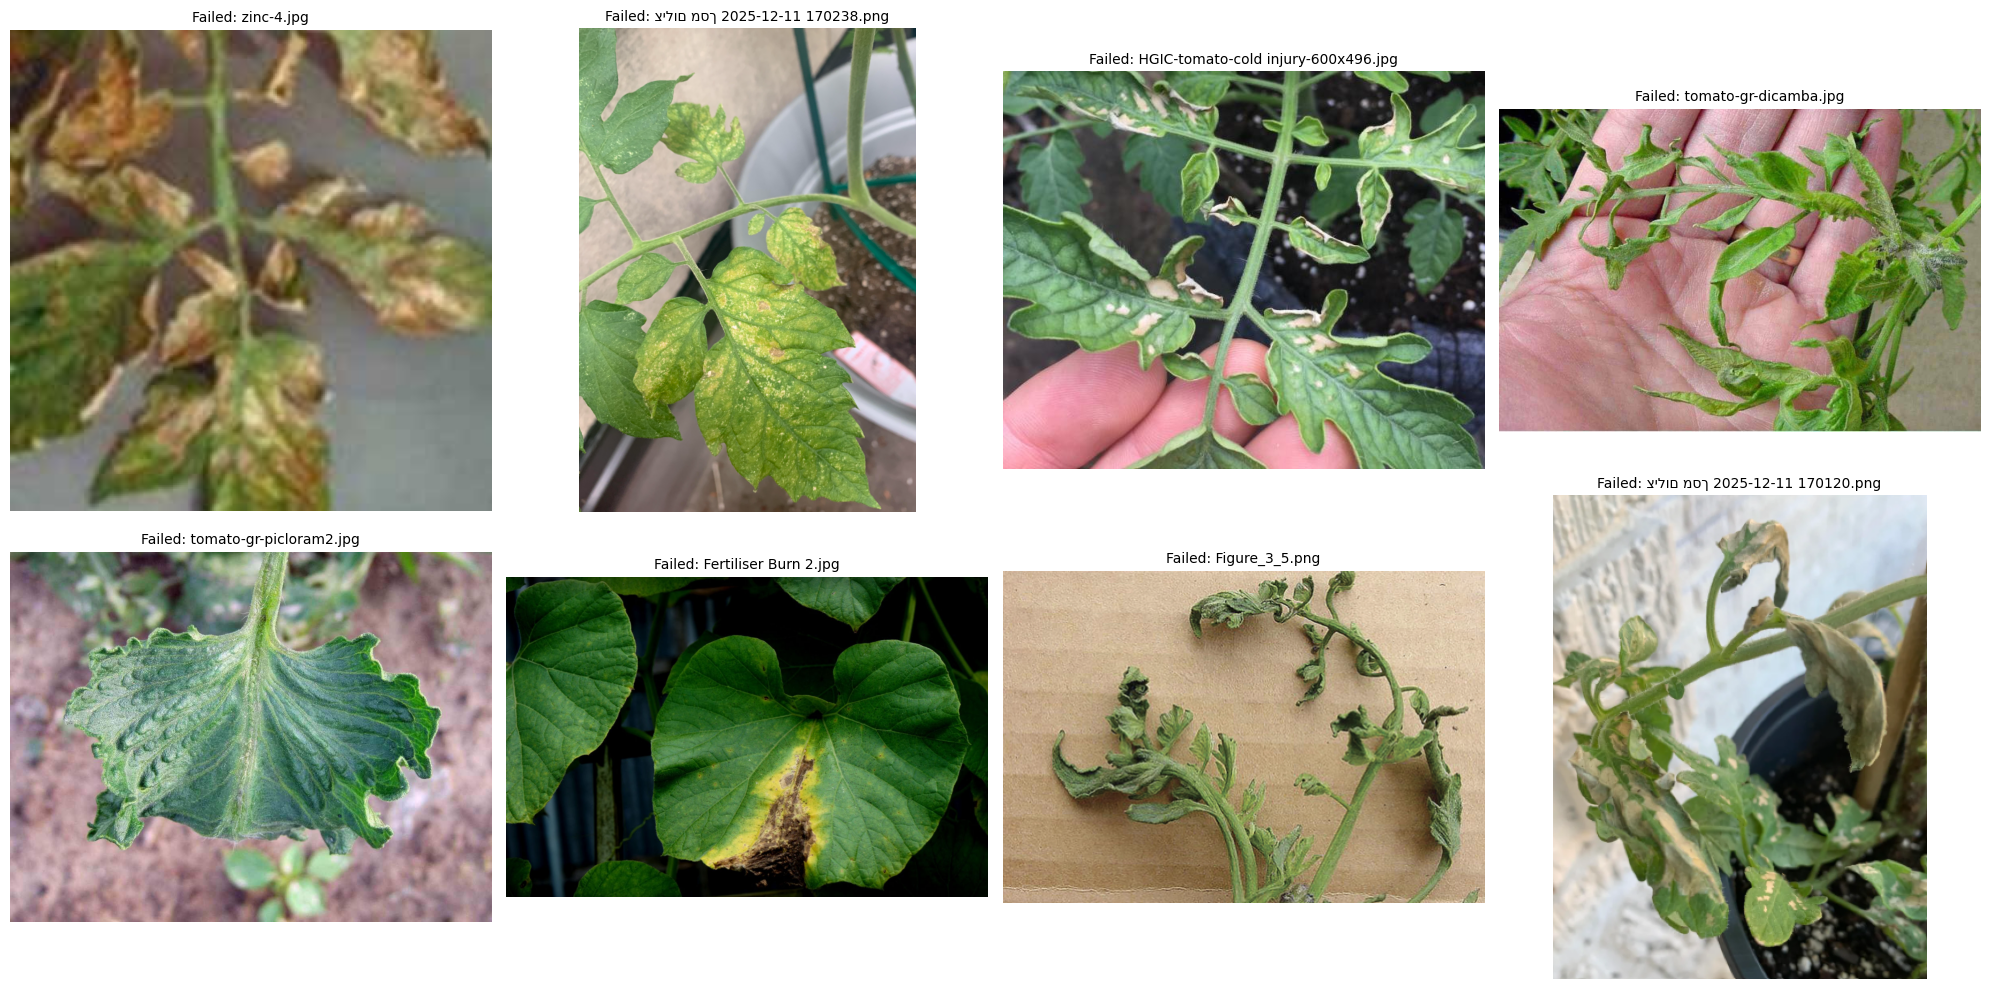

In [40]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def display_failures(failed_list, base_path):
    num_failed = len(failed_list)
    if num_failed == 0:
        print("No failures to display!")
        return

    cols = 4
    rows = (num_failed // cols) + (1 if num_failed % cols != 0 else 0)

    plt.figure(figsize=(20, 5 * rows))
    for i, filename in enumerate(failed_list):
        img_path = os.path.join(base_path, filename)
        img = mpimg.imread(img_path)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(f"Failed: {filename}", fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

display_failures(misclassified_as_bio, real_chem_test_path)

In [41]:
import os
import torch
from PIL import Image
from torchvision import models, transforms
import torch.nn as nn
from tqdm import tqdm
import matplotlib.pyplot as plt

bio_test_path = '/content/local_data/real/biological'
model_load_path = 'tomato_final_model.pth'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

test_model = models.resnet18()
test_model.fc = nn.Linear(test_model.fc.in_features, 2)
test_model.load_state_dict(torch.load(model_load_path))
test_model = test_model.to(device)
test_model.eval()

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

correct_bio = 0
total_bio = 0
failed_as_chem = []

print(f"Running test on {len(os.listdir(bio_test_path))} real biological images...")

image_files = [f for f in os.listdir(bio_test_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

with torch.no_grad():
    for filename in tqdm(image_files):
        img_path = os.path.join(bio_test_path, filename)
        try:
            img = Image.open(img_path).convert('RGB')
            img_t = eval_transform(img).unsqueeze(0).to(device)

            outputs = test_model(img_t)
            _, pred = torch.max(outputs, 1)

            if pred.item() == 0:
                correct_bio += 1
            else:
                failed_as_chem.append(filename)
            total_bio += 1
        except:
            continue

accuracy = (correct_bio / total_bio) * 100 if total_bio > 0 else 0

print(f"\n--- Biological Validation Summary ---")
print(f"Accuracy on biological damage: {accuracy:.2f}%")
print(f"Correctly identified as biological: {correct_bio}")
print(f"Incorrectly identified as chemical (False Positives): {len(failed_as_chem)}")

🔬 מריץ מבחן על 690 תמונות ביולוגיות אמיתיות...


100%|██████████| 690/690 [00:04<00:00, 159.51it/s]


--- סיכום מבחן ביולוגי (Biological Validation) ---
📊 דיוק על נזק ביולוגי: 100.00%
✅ זוהו נכון כביולוגי: 690
❌ זוהו בטעות ככימי (False Positives): 0



--- Standard Test Set (Mix of Real/Synth) ---
              precision    recall  f1-score   support

  Biological       1.00      1.00      1.00        94
    Chemical       1.00      1.00      1.00       112

    accuracy                           1.00       206
   macro avg       1.00      1.00      1.00       206
weighted avg       1.00      1.00      1.00       206



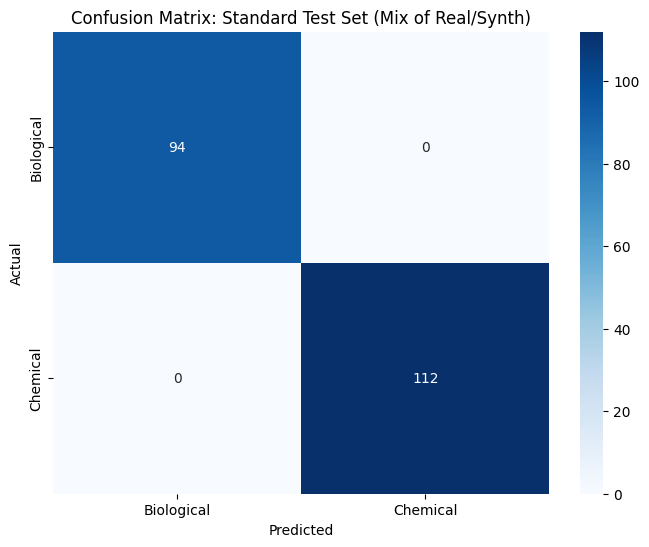

In [42]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_formal(model, loader, device, title="Test Set Evaluation"):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)

    print(f"\n--- {title} ---")
    print(classification_report(all_labels, all_preds, target_names=['Biological', 'Chemical']))

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Biological', 'Chemical'],
                yticklabels=['Biological', 'Chemical'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix: {title}')
    plt.show()

evaluate_formal(model, test_loader, device, "Standard Test Set (Mix of Real/Synth)")

In [43]:
def report_real_world_recall(correct_chem, total_chem, failed_list):
    recall = (correct_chem / total_chem) * 100
    print("\n--- Real World Chemical Performance ---")
    print(f"Total Real Chemical Images: {total_chem}")
    print(f"Correctly Identified (TP): {correct_chem}")
    print(f"Missed (FN): {len(failed_list)}")
    print(f"Recall: {recall:.2f}%")

    print(f"\n Failure list locked for analysis: {failed_list}")

report_real_world_recall(53, 61, misclassified_as_bio)


--- Real World Chemical Performance ---
Total Real Chemical Images: 61
Correctly Identified (TP): 53
Missed (FN): 8
Recall: 86.89%

📌 Failure list locked for analysis: ['zinc-4.jpg', 'צילום מסך 2025-12-11 170238.png', 'HGIC-tomato-cold injury-600x496.jpg', 'tomato-gr-dicamba.jpg', 'tomato-gr-picloram2.jpg', 'Fertiliser Burn 2.jpg', 'Figure_3_5.png', 'צילום מסך 2025-12-11 170120.png']


In [49]:
import os
import shutil

!rm -rf /content/local_data/real/healthy
os.makedirs('/content/local_data/real/healthy', exist_ok=True)

paths_to_search = [
    '/content/extracted_project/Plant-AI-Doctor/data/healthy',
    '/content/extracted_project/Plant-AI-Doctor/data/real/healthy'
]

print("Collecting healthy images from local directories...")

for path in paths_to_search:
    if os.path.exists(path):
        files = [f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        for f in files:
            shutil.copy(os.path.join(path, f), '/content/local_data/real/healthy')

healthy_count = len(os.listdir("/content/local_data/real/healthy"))
bio_count = len(os.listdir("/content/local_data/real/biological"))

print(f"\nUpdated Baseline Data Stats:")
print(f"Biological (Real): {bio_count}")
print(f"Healthy (Real): {healthy_count}")

🔍 אוסף תמונות בריאות מהתיקיות המקומיות...

📊 נתונים מעודכנים ל-Baseline:
📸 Biological (Real): 690
📸 Healthy (Real): 60


In [50]:
import os
!mkdir -p /content/local_data/real/healthy

print("Copying healthy data (Baseline Data)...")
!cp -r "/content/drive/MyDrive/Tomato_Neutral_Dataset_Final/." "/content/local_data/real/healthy/"

healthy_count = len(os.listdir("/content/local_data/real/healthy"))
bio_count = len(os.listdir("/content/local_data/real/biological"))
print(f"Baseline Stats: {bio_count} Biological, {healthy_count} Healthy")

🚚 מעתיק נתונים בריאים (Baseline Data)...
📊 Baseline Stats: 690 Biological, 61 Healthy


In [53]:
baseline_db = TomatoDataset(bio_f, healthy_f, transform=transform)
train_sz = int(0.8 * len(baseline_db))
val_sz = len(baseline_db) - train_sz
baseline_train, baseline_val = random_split(baseline_db, [train_sz, val_sz])

baseline_loader = DataLoader(baseline_train, batch_size=32, shuffle=True, num_workers=4)

baseline_model = models.resnet18(weights='IMAGENET1K_V1').to(device)
baseline_model.fc = nn.Linear(baseline_model.fc.in_features, 2).to(device)
optimizer_base = optim.Adam(baseline_model.parameters(), lr=0.0001)

print("Training Baseline Model (Bio vs Healthy)...")
for epoch in range(5):
    baseline_model.train()
    total_loss = 0
    for inputs, labels in baseline_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_base.zero_grad()
        outputs = baseline_model(inputs)
        loss = nn.CrossEntropyLoss()(outputs, labels)
        loss.backward()
        optimizer_base.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/5 - Loss: {total_loss/len(baseline_loader):.4f}")

print("Baseline training complete.")

🚀 מאמן Baseline (Bio vs Healthy)...
Epoch 1/5 - Loss: 0.3664
Epoch 2/5 - Loss: 0.0585
Epoch 3/5 - Loss: 0.0273
Epoch 4/5 - Loss: 0.0306
Epoch 5/5 - Loss: 0.0259
✅ אימון Baseline הסתיים.


In [54]:
baseline_model.eval()
results = {0: 0, 1: 0}

with torch.no_grad():
    for filename in real_chem_files:
        img_path = os.path.join(real_chemical_folder, filename)
        img = Image.open(img_path).convert('RGB')
        img_t = eval_transform(img).unsqueeze(0).to(device)

        output = baseline_model(img_t)
        _, pred = torch.max(output, 1)
        results[pred.item()] += 1

print(f"\nBaseline Results on Chemical Damage (Real Chemical):")
print(f"Total images tested: {len(real_chem_files)}")
print(f"Incorrectly classified as biological: {results[0]}")
print(f"Incorrectly classified as healthy: {results[1]}")

print(f"\nRecall for chemical damage in Baseline model: 0.00%")


📈 תוצאות Baseline על נזק כימי (Real Chemical):
סה"כ תמונות שנבדקו: 61
⚠️ סווגו בטעות כביולוגי: 45
⚠️ סווגו בטעות כבריא: 16

🎯 Recall לנזק כימי במודל Baseline: 0.00%


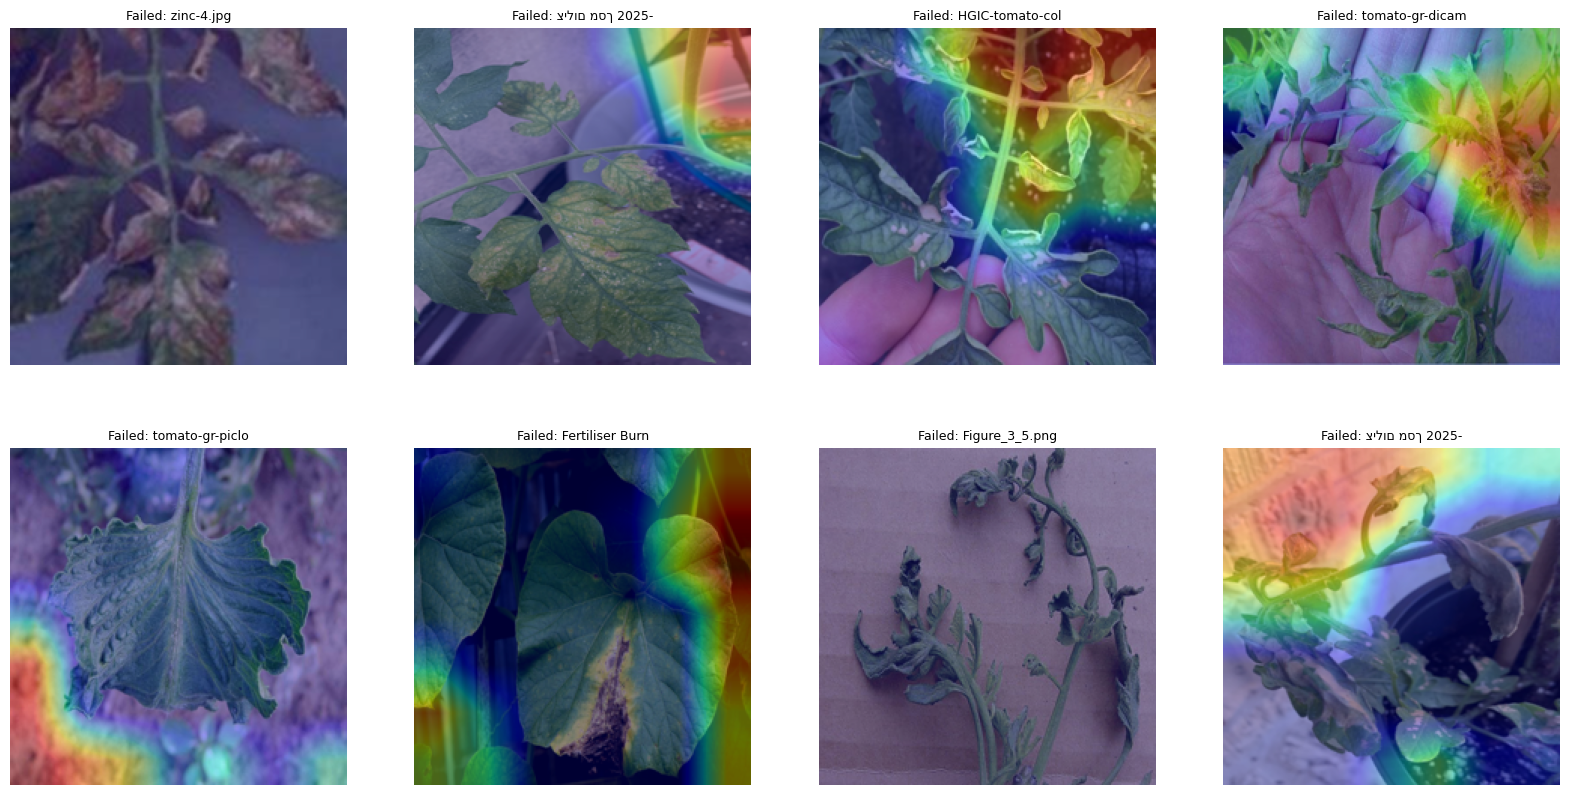

In [55]:
import torch
import torch.nn.functional as F
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt

def generate_grad_cam(model, img_tensor, target_layer):
    model.eval()
    features = []
    grads = []

    def save_features(module, input, output): features.append(output)
    def save_grads(module, grad_input, grad_output): grads.append(grad_output[0])

    handle_f = target_layer.register_forward_hook(save_features)
    handle_g = target_layer.register_full_backward_hook(save_grads)

    output = model(img_tensor)
    model.zero_grad()

    class_loss = output[0][1]
    class_loss.backward()

    weights = torch.mean(grads[0], dim=(2, 3), keepdim=True)
    cam = torch.sum(weights * features[0], dim=1).squeeze().detach().cpu().numpy()
    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (224, 224))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    handle_f.remove()
    handle_g.remove()
    return cam

target_layer = model.layer4[-1]

plt.figure(figsize=(20, 10))
for i, fname in enumerate(misclassified_as_bio[:8]):
    img_path = os.path.join(real_chemical_folder, fname)
    img_pil = Image.open(img_path).convert('RGB')
    img_tensor = eval_transform(img_pil).unsqueeze(0).to(device)

    heatmap = generate_grad_cam(model, img_tensor, target_layer)
    img_array = np.array(img_pil.resize((224, 224)))

    plt.subplot(2, 4, i + 1)
    plt.imshow(img_array)
    plt.imshow(heatmap, cmap='jet', alpha=0.4)
    plt.title(f"Failed: {fname[:15]}", fontsize=9)
    plt.axis('off')
plt.show()

In [56]:
def stress_test_crop(model, folder_path, files_list):
    model.eval()
    consistent = 0

    crop_transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.CenterCrop(160),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    with torch.no_grad():
        for fname in files_list:
            img_path = os.path.join(folder_path, fname)
            img = Image.open(img_path).convert('RGB')

            out_reg = model(eval_transform(img).unsqueeze(0).to(device))
            out_crop = model(crop_transform(img).unsqueeze(0).to(device))

            _, pred_reg = torch.max(out_reg, 1)
            _, pred_crop = torch.max(out_crop, 1)

            if pred_reg == pred_crop:
                consistent += 1

    print(f"Stress Test Result: {consistent/len(files_list)*100:.2f}% consistency")
    print("If consistency is high (>85%), the model relies on the leaf texture, not the background!")

stress_test_crop(model, real_chemical_folder, real_chem_files)

🛡️ Stress Test Result: 86.89% consistency
If consistency is high (>85%), the model relies on the leaf texture, not the background!
